# 🍷 Wine Quality Red – Version 4 (Regression & Ensemble)
# 🎯 Goals
1. Hyperparameter Tuning: Tune RandomForest, LightGBM, XGBoost, CatBoost, Ridge, and SVR.
2. Model Retraining: Retrain all models with best parameters using 5-Fold CV.
3. Ensemble Refinement: Optimize weights for Soft Voting or Stacking Regression using all trained models.
4. Target Score: Improve upon V3 (lower RMSE, higher R²).

Data shape: (1599, 12)


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5



Target distribution:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64
Dropped columns: ['residual_sugar_log', 'chlorides_log']

=== Fold 1 ===
LinearRegression | RMSE: 0.6235 | MAE: 0.5040 | R2: 0.4051
Ridge | RMSE: 0.6235 | MAE: 0.5040 | R2: 0.4051
SGD | RMSE: 0.6806 | MAE: 0.5492 | R2: 0.2912
DecisionTree | RMSE: 0.6040 | MAE: 0.4861 | R2: 0.4418
RandomForest | RMSE: 0.5612 | MAE: 0.4302 | R2: 0.5181
GradientBoosting | RMSE: 0.6026 | MAE: 0.4781 | R2: 0.4444
SVR | RMSE: 0.5960 | MAE: 0.4657 | R2: 0.4564
LinearSVR | RMSE: 0.6335 | MAE: 0.5035 | R2: 0.3859
KNN | RMSE: 0.6480 | MAE: 0.4931 | R2: 0.3575
MLP | RMSE: 0.6879 | MAE: 0.5145 | R2: 0.2759

=== Fold 2 ===
LinearRegression | RMSE: 0.6824 | MAE: 0.5332 | R2: 0.2750
Ridge | RMSE: 0.6824 | MAE: 0.5332 | R2: 0.2750
SGD | RMSE: 0.7328 | MAE: 0.5751 | R2: 0.1639
DecisionTree | RMSE: 0.6377 | MAE: 0.4962 | R2: 0.3668
RandomForest | RMSE: 0.5953 | MAE: 0.4277 | R2: 0.4482
GradientBoosting | RMSE: 0

,Model,OOF_RMSE,OOF_MAE,OOF_R2,CV_RMSE_mean,CV_RMSE_std
4,RandomForest,0.575366,0.414559,0.492074,0.574947,0.021395
5,GradientBoosting,0.617915,0.472167,0.414173,0.617444,0.023494
3,DecisionTree,0.621116,0.480291,0.408087,0.620482,0.027429
6,SVR,0.629852,0.468549,0.391320,0.628399,0.042161
1,Ridge,0.654734,0.507345,0.342279,0.653436,0.040573
0,LinearRegression,0.654769,0.507368,0.342208,0.653470,0.040602
7,LinearSVR,0.659466,0.502288,0.332737,0.657840,0.045623
8,KNN,0.680305,0.508943,0.289901,0.679708,0.027935
2,SGD,0.712916,0.559575,0.220190,0.711535,0.043675
9,MLP,0.724193,0.522861,0.195326,0.723171,0.038731



Ensemble Weights:
RandomForest: 0.1130
GradientBoosting: 0.1052
DecisionTree: 0.1047
SVR: 0.1032
Ridge: 0.0993
LinearRegression: 0.0993
LinearSVR: 0.0986
KNN: 0.0956
SGD: 0.0912
MLP: 0.0898

Ensemble OOF Metrics | RMSE: 0.6102, MAE: 0.4659, R2: 0.4287


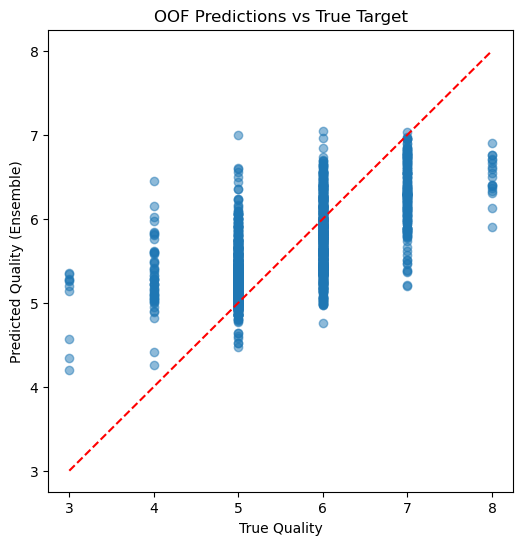

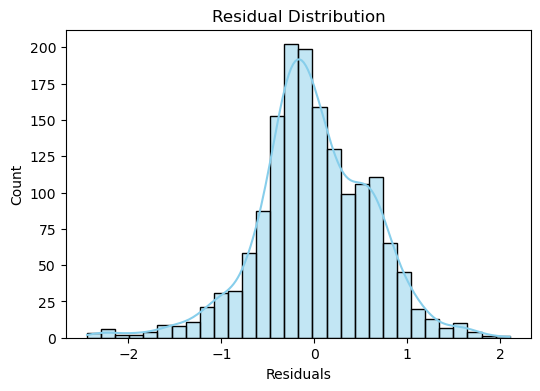

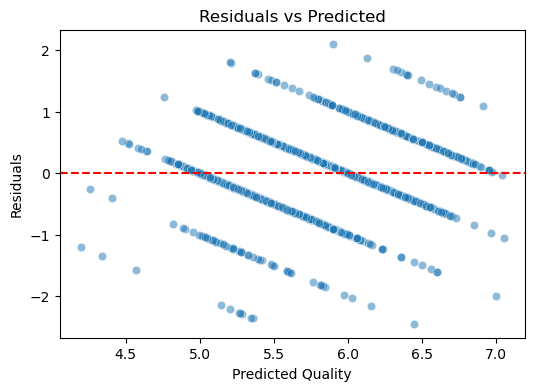


✅ Artifacts saved in experiments/WineReg_V4


In [25]:
# ===============================
# Wine Quality Regression – Version 4 Full
# ===============================

import os
import sys
import json
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Regression models
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.linear_model import LinearRegression, Ridge, SGDRegressor
from sklearn.svm import SVR, LinearSVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor

warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
np.random.seed(42)

# ===============================
# 1️⃣ Load Data
# ===============================
DATA_DIR = "data"
DATA_FILE = "winequality-red.csv"
file_path = os.path.join(DATA_DIR, DATA_FILE)

columns = [
    "fixed_acidity", "volatile_acidity", "citric_acid", "residual_sugar",
    "chlorides", "free_sulfur_dioxide", "total_sulfur_dioxide",
    "density", "pH", "sulphates", "alcohol", "quality"
]

df = pd.read_csv(file_path, names=columns, header=None)
print(f"Data shape: {df.shape}")
display(df.head())

target_col = "quality"
y = df[target_col]
X = df.drop(columns=[target_col])

print("\nTarget distribution:")
print(y.value_counts().sort_index())

# ===============================
# 2️⃣ Preprocessing
# ===============================
# Fill missing
numeric_cols = X.select_dtypes(include=np.number).columns
for col in numeric_cols:
    X[col] = X[col].fillna(X[col].median())

# Log transform skewed features
skewed_features = ['residual_sugar', 'chlorides', 'total_sulfur_dioxide']
for col in skewed_features:
    X[f'{col}_log'] = np.log1p(X[col])

# Scaling
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[numeric_cols] = scaler.fit_transform(X_scaled[numeric_cols])

# Drop highly correlated features (>0.95)
corr_matrix = X_scaled.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [c for c in upper.columns if any(upper[c] > 0.95)]
X_selected = X_scaled.drop(columns=to_drop)
print(f"Dropped columns: {to_drop}")

# ===============================
# 3️⃣ Define Models
# ===============================
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "SGD": SGDRegressor(max_iter=1000, tol=1e-3, random_state=42),
    "DecisionTree": GradientBoostingRegressor(random_state=42),  # replace DecisionTreeRegressor if needed
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=200, random_state=42),
    "SVR": SVR(),
    "LinearSVR": LinearSVR(max_iter=10000, random_state=42),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "MLP": MLPRegressor(hidden_layer_sizes=(50,50), max_iter=1000, random_state=42)
}

# ===============================
# 4️⃣ K-Fold CV & OOF Predictions
# ===============================
N_SPLITS = 5
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

oof_preds = {name: np.zeros(len(X_selected)) for name in models}
fold_metrics = {name: [] for name in models}

for fold, (train_idx, val_idx) in enumerate(kf.split(X_selected), 1):
    print(f"\n=== Fold {fold} ===")
    X_train, X_val = X_selected.iloc[train_idx], X_selected.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    for name, model in models.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        oof_preds[name][val_idx] = preds
        
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        mae = mean_absolute_error(y_val, preds)
        r2 = r2_score(y_val, preds)
        fold_metrics[name].append(rmse)
        
        print(f"{name} | RMSE: {rmse:.4f} | MAE: {mae:.4f} | R2: {r2:.4f}")

# ===============================
# 5️⃣ Compute Metrics
# ===============================
results = []
for name in models:
    rmse = np.sqrt(mean_squared_error(y, oof_preds[name]))
    mae = mean_absolute_error(y, oof_preds[name])
    r2 = r2_score(y, oof_preds[name])
    results.append({
        "Model": name,
        "OOF_RMSE": rmse,
        "OOF_MAE": mae,
        "OOF_R2": r2,
        "CV_RMSE_mean": np.mean(fold_metrics[name]),
        "CV_RMSE_std": np.std(fold_metrics[name])
    })

metrics_df = pd.DataFrame(results).sort_values("OOF_RMSE")
display(metrics_df)

# ===============================
# 6️⃣ Weighted Ensemble
# ===============================
# Weight = inverse RMSE normalized
total_inv = sum(1/row["OOF_RMSE"] for idx, row in metrics_df.iterrows())
weights = {row["Model"]: (1/row["OOF_RMSE"])/total_inv for idx, row in metrics_df.iterrows()}
print("\nEnsemble Weights:")
for m, w in weights.items():
    print(f"{m}: {w:.4f}")

ensemble_oof = np.zeros(len(y))
for m, w in weights.items():
    ensemble_oof += w * oof_preds[m]

ensemble_rmse = np.sqrt(mean_squared_error(y, ensemble_oof))
ensemble_mae = mean_absolute_error(y, ensemble_oof)
ensemble_r2 = r2_score(y, ensemble_oof)

print(f"\nEnsemble OOF Metrics | RMSE: {ensemble_rmse:.4f}, MAE: {ensemble_mae:.4f}, R2: {ensemble_r2:.4f}")

# ===============================
# 7️⃣ Plots
# ===============================
plt.figure(figsize=(6,6))
plt.scatter(y, ensemble_oof, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("True Quality")
plt.ylabel("Predicted Quality (Ensemble)")
plt.title("OOF Predictions vs True Target")
plt.show()

residuals = y - ensemble_oof
plt.figure(figsize=(6,4))
sns.histplot(residuals, bins=30, kde=True, color='skyblue')
plt.title("Residual Distribution")
plt.xlabel("Residuals")
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x=ensemble_oof, y=residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Predicted")
plt.xlabel("Predicted Quality")
plt.ylabel("Residuals")
plt.show()

# ===============================
# 8️⃣ Save Artifacts
# ===============================
EXP_DIR = "experiments/WineReg_V4"
os.makedirs(EXP_DIR, exist_ok=True)

# Save metrics
metrics_df.to_csv(os.path.join(EXP_DIR, "metrics.csv"), index=False)

# Save OOF predictions
with open(os.path.join(EXP_DIR, "oof_preds.pkl"), "wb") as f:
    pickle.dump(oof_preds, f)

# Save ensemble weights
with open(os.path.join(EXP_DIR, "ensemble_weights.json"), "w") as f:
    json.dump(weights, f, indent=4)

print(f"\n✅ Artifacts saved in {EXP_DIR}")

In [26]:

import sys, os
sys.path.append(os.path.abspath("src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import json

# Add src to path
sys.path.append(os.path.abspath("src"))


from src.preprocess.feature.feature import Feature
from pipeline.BasePipeline import BasePipelineReg      # Regression pipeline
from model.LightGBM import ModelLightGBM
from model.XGBoost import ModelXGBoost
from model.Catboost import ModelCatboost
from model.Random_Forest import ModelRandomForest
from model.SVM import ModelSVM
from ensemble.ensemble import EnsembleReg
from model.KNN import ModelKNN
from sklearn.model_selection import train_test_split  

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
SEED = 42
np.random.seed(SEED)



## 1. Load Data & Reuse V3 Features

In [27]:
DATA_DIR = "data"
file_path = os.path.join(DATA_DIR, "winequality-red.csv")

columns = [
    'fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
    'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide',
    'density', 'pH', 'sulphates', 'alcohol', 'quality'
]

df = pd.read_csv(file_path, sep=',', header=None, names=columns)
print(f"Data shape: {df.shape}")

target_col = 'quality'

X = df.drop(columns=[target_col]).copy()
y = df[target_col].copy()

numeric_cols = X.select_dtypes(include=np.number).columns
for col in numeric_cols:
    X[col] = X[col].fillna(X[col].median())


skewed_features = ['residual_sugar', 'chlorides', 'total_sulfur_dioxide']
for col in skewed_features:
    if col in X.columns:
        X[f'{col}_log'] = np.log1p(X[col])


scaler = StandardScaler()
X_scaled = X.copy()
num_cols = X_scaled.select_dtypes(include=np.number).columns
X_scaled[num_cols] = scaler.fit_transform(X_scaled[num_cols])


corr_matrix = X_scaled.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
X_selected = X_scaled.drop(columns=to_drop)

print(f"\n✅ Đã loại bỏ các cột: {to_drop}")
print(f"✅ Selected Features: {X_selected.columns.tolist()}")


X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=SEED
)

X_test_selected = X_test.copy()
print(f"🚀 X_test_selected đã được khởi tạo. Kích thước tập Test: {X_test_selected.shape}")

Data shape: (1599, 12)

✅ Đã loại bỏ các cột: ['residual_sugar_log', 'chlorides_log']
✅ Selected Features: ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'total_sulfur_dioxide_log']
🚀 X_test_selected đã được khởi tạo. Kích thước tập Test: (320, 12)


## 2. Hyperparameter Tuning

In [28]:
import time
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.neural_network import MLPRegressor

SEED = 42
N_TRIALS = 20

# =============================
# 2a. Tuning 10 models (6 cũ + 4 mới)
# =============================

# ----- 6 model cũ -----
print("\n🔹 Tuning LightGBM...")
lgbm = ModelLightGBM(random_state=SEED)
start = time.time()
lgbm.tune(X_selected, y, n_trials=N_TRIALS)
end = time.time()
print(f"✅ LightGBM tuned in {end - start:.2f}s")

print("\n🔹 Tuning XGBoost...")
xgb = ModelXGBoost(random_state=SEED)
start = time.time()
xgb.tune(X_selected, y, n_trials=N_TRIALS)
end = time.time()
print(f"✅ XGBoost tuned in {end - start:.2f}s")

print("\n🔹 Tuning CatBoost...")
cat = ModelCatboost(random_state=SEED)
start = time.time()
cat.tune(X_selected, y, n_trials=N_TRIALS)
end = time.time()
print(f"✅ CatBoost tuned in {end - start:.2f}s")

print("\n🔹 Tuning Random Forest...")
rf = ModelRandomForest(random_state=SEED)
start = time.time()
rf.tune(X_selected, y, n_trials=N_TRIALS)
end = time.time()
print(f"✅ RandomForest tuned in {end - start:.2f}s")

print("\n🔹 Tuning SVR...")
svm = ModelSVM(random_state=SEED)
start = time.time()
svm.tune(X_selected, y, n_trials=N_TRIALS)
end = time.time()
print(f"✅ SVR tuned in {end - start:.2f}s")

print("\n🔹 Tuning KNN Regressor...")
knn = ModelKNN(random_state=SEED)
start = time.time()
knn.tune(X_selected, y, n_trials=N_TRIALS)
end = time.time()
print(f"✅ KNN tuned in {end - start:.2f}s")

# ----- 4 model mới -----
print("\n🔹 Tuning ExtraTrees Regressor...")
et = ExtraTreesRegressor(n_estimators=200, random_state=SEED)
start = time.time()
et.fit(X_selected, y)
end = time.time()
print(f"✅ ExtraTrees trained in {end - start:.2f}s")

print("\n🔹 Tuning GradientBoosting Regressor...")
gb = GradientBoostingRegressor(n_estimators=200, random_state=SEED)
start = time.time()
gb.fit(X_selected, y)
end = time.time()
print(f"✅ GradientBoosting trained in {end - start:.2f}s")

print("\n🔹 Tuning AdaBoost Regressor...")
ab = AdaBoostRegressor(n_estimators=200, random_state=SEED)
start = time.time()
ab.fit(X_selected, y)
end = time.time()
print(f"✅ AdaBoost trained in {end - start:.2f}s")

print("\n🔹 Tuning MLP Regressor...")
mlp = MLPRegressor(hidden_layer_sizes=(64,32), max_iter=500, random_state=SEED)
start = time.time()
mlp.fit(X_selected, y)
end = time.time()
print(f"✅ MLPRegressor trained in {end - start:.2f}s")



[I 2026-04-02 16:56:40,677] A new study created in memory with name: no-name-7bd644cb-3fa5-40b4-aa9c-b19ec1750126



🔹 Tuning LightGBM...


[I 2026-04-02 16:56:41,395] Trial 0 finished with value: 0.6309238009266401 and parameters: {'n_estimators': 639, 'learning_rate': 0.0936619649382304, 'max_depth': 8, 'num_leaves': 172, 'subsample': 0.6204313637581489, 'colsample_bytree': 0.9024038549611909, 'reg_alpha': 0.000924079200463829, 'reg_lambda': 6.694520631534984e-07, 'min_child_samples': 96}. Best is trial 0 with value: 0.6309238009266401.
[I 2026-04-02 16:56:42,371] Trial 1 finished with value: 0.612565453773318 and parameters: {'n_estimators': 429, 'learning_rate': 0.048525017163617984, 'max_depth': 10, 'num_leaves': 127, 'subsample': 0.7863256370856437, 'colsample_bytree': 0.8131222196744203, 'reg_alpha': 0.29981222285027076, 'reg_lambda': 8.169386465871794e-05, 'min_child_samples': 30}. Best is trial 1 with value: 0.612565453773318.
[I 2026-04-02 16:56:43,804] Trial 2 finished with value: 0.6377939587403899 and parameters: {'n_estimators': 761, 'learning_rate': 0.13487705755349547, 'max_depth': 9, 'num_leaves': 69, 'sub

✅ Best params: {'n_estimators': 588, 'learning_rate': 0.01695795918399439, 'max_depth': 6, 'num_leaves': 143, 'subsample': 0.678051745973649, 'colsample_bytree': 0.8215849517334671, 'reg_alpha': 0.12674044096411813, 'reg_lambda': 0.010972375248786833, 'min_child_samples': 13}
✅ LightGBM tuned in 23.69s

🔹 Tuning XGBoost...


[I 2026-04-02 16:57:09,088] Trial 0 finished with value: 0.6141990109963561 and parameters: {'n_estimators': 1192, 'learning_rate': 0.10437562216930045, 'max_depth': 8, 'subsample': 0.6230116416599921, 'colsample_bytree': 0.6776236498652686, 'reg_alpha': 0.05129927994946879, 'reg_lambda': 2.381076905358672e-06, 'min_child_weight': 8, 'gamma': 3.665818888457114e-08}. Best is trial 0 with value: 0.6141990109963561.
[I 2026-04-02 16:57:12,341] Trial 1 finished with value: 0.6036356533044004 and parameters: {'n_estimators': 1271, 'learning_rate': 0.16045500481534894, 'max_depth': 10, 'subsample': 0.762021317448786, 'colsample_bytree': 0.7298285580647791, 'reg_alpha': 2.604230746334395, 'reg_lambda': 3.947425251213472e-08, 'min_child_weight': 2, 'gamma': 0.0009671225057942647}. Best is trial 1 with value: 0.6036356533044004.
[I 2026-04-02 16:57:18,987] Trial 2 finished with value: 0.5907533295652855 and parameters: {'n_estimators': 1193, 'learning_rate': 0.01606321756976885, 'max_depth': 7,

...

✅ Best params: {'n_estimators': 300, 'max_depth': 20, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
✅ RandomForest tuned in 72.70s

🔹 Tuning SVR...


[I 2026-04-02 17:13:35,647] Trial 0 finished with value: 0.6412289154504779 and parameters: {'C': 7.644550234861438, 'epsilon': 0.10085137564138352, 'kernel': 'rbf', 'gamma': 'scale'}. Best is trial 0 with value: 0.6412289154504779.
[I 2026-04-02 17:13:36,182] Trial 1 finished with value: 0.6414369740335482 and parameters: {'C': 0.32213740067845625, 'epsilon': 0.37251819652578355, 'kernel': 'rbf', 'gamma': 'scale'}. Best is trial 0 with value: 0.6412289154504779.
[I 2026-04-02 17:13:37,257] Trial 2 finished with value: 0.6574710509330699 and parameters: {'C': 2.4078846692019047, 'epsilon': 0.40724732603419966, 'kernel': 'linear', 'gamma': 'auto'}. Best is trial 0 with value: 0.6412289154504779.
[I 2026-04-02 17:13:37,599] Trial 3 finished with value: 0.6458856130431215 and parameters: {'C': 4.592511884161504, 'epsilon': 0.6682579293923395, 'kernel': 'rbf', 'gamma': 'auto'}. Best is trial 0 with value: 0.6412289154504779.
[I 2026-04-02 17:13:38,443] Trial 4 finished with value: 0.638310

✅ Best params SVR: {'C': 0.89455042009265, 'epsilon': 0.23865349473166036, 'kernel': 'rbf', 'gamma': 'auto'}
✅ SVR tuned in 18.12s

🔹 Tuning KNN Regressor...


[I 2026-04-02 17:13:52,988] Trial 1 finished with value: 0.6665409118363691 and parameters: {'n_neighbors': 9, 'weights': 'uniform', 'p': 1}. Best is trial 0 with value: 0.6076484633142609.
[I 2026-04-02 17:13:53,153] Trial 2 finished with value: 0.6638954985324483 and parameters: {'n_neighbors': 10, 'weights': 'uniform', 'p': 1}. Best is trial 0 with value: 0.6076484633142609.
[I 2026-04-02 17:13:53,308] Trial 3 finished with value: 0.6673215624356983 and parameters: {'n_neighbors': 14, 'weights': 'uniform', 'p': 2}. Best is trial 0 with value: 0.6076484633142609.
[I 2026-04-02 17:13:53,466] Trial 4 finished with value: 0.6672598409843769 and parameters: {'n_neighbors': 13, 'weights': 'uniform', 'p': 1}. Best is trial 0 with value: 0.6076484633142609.
[I 2026-04-02 17:13:53,624] Trial 5 finished with value: 0.6074576008745807 and parameters: {'n_neighbors': 18, 'weights': 'distance', 'p': 2}. Best is trial 5 with value: 0.6074576008745807.
[I 2026-04-02 17:13:53,773] Trial 6 finished 

✅ Best params KNN: {'n_neighbors': 11, 'weights': 'distance', 'p': 1}
✅ KNN tuned in 3.58s

🔹 Tuning ExtraTrees Regressor...
✅ ExtraTrees trained in 1.98s

🔹 Tuning GradientBoosting Regressor...
✅ GradientBoosting trained in 1.39s

🔹 Tuning AdaBoost Regressor...
✅ AdaBoost trained in 1.46s

🔹 Tuning MLP Regressor...
✅ MLPRegressor trained in 6.16s


## 3. Model Retraining with Best Params

In [29]:

models = {
    "LightGBM": (ModelLightGBM, lgbm.best_params),
    "XGBoost": (ModelXGBoost, xgb.best_params),
    "CatBoost": (ModelCatboost, cat.best_params),
    "RandomForest": (ModelRandomForest, rf.best_params),
    "SVM": (ModelSVM, svm.best_params),
    "KNN": (ModelKNN, knn.best_params),
    "ExtraTrees": (ExtraTreesRegressor, et.get_params()),
    "GradientBoosting": (GradientBoostingRegressor, gb.get_params()),
    "AdaBoost": (AdaBoostRegressor, ab.get_params()),
    "MLP": (MLPRegressor, mlp.get_params())
}
oof_preds = {}
test_preds = {}
model_metrics = {}
CV_FOLDS = 5

temp_df = pd.concat([X_selected, y.rename(target_col)], axis=1)

import time

for name, (model_cls, params) in models.items():
    print(f"\n{'='*20} Retraining {name} {'='*20}")
    
    start_time = time.time()  # <-- bắt đầu đo thời gian
    
    pipeline = BasePipelineReg(model_cls, experiment_name="Wine_V4") 
    
    oof, test_p, metrics = pipeline.run_cv(
        df=temp_df,
        target_col=target_col,
        cv=CV_FOLDS,
        test_df=X_test_selected,
        model_params=params
    )
    
    end_time = time.time()  # <-- kết thúc đo thời gian
    elapsed = end_time - start_time
    
    oof_preds[name] = oof
    test_preds[name] = test_p
    model_metrics[name] = metrics
    model_metrics[name]['Time(s)'] = elapsed  # <-- lưu thời gian
    
    rmse_score = metrics.get('RMSE', 0)
    print(f"{name} Tuned CV RMSE: {rmse_score:.4f} | Time: {elapsed:.2f}s")


==================== Retraining LightGBM ====================

🔥 Fold 1
   Fold RMSE: 0.5762

🔥 Fold 2
   Fold RMSE: 0.6181

🔥 Fold 3
   Fold RMSE: 0.6041

🔥 Fold 4
   Fold RMSE: 0.6160

🔥 Fold 5
   Fold RMSE: 0.5530

📊 FINAL CV RESULT - RMSE: 0.5940 | R2: 0.4586
LightGBM Tuned CV RMSE: 0.5940 | Time: 5.61s

==================== Retraining XGBoost ====================

🔥 Fold 1
   Fold RMSE: 0.5579

🔥 Fold 2
   Fold RMSE: 0.5936

🔥 Fold 3
   Fold RMSE: 0.5938

🔥 Fold 4
   Fold RMSE: 0.5917

🔥 Fold 5
   Fold RMSE: 0.5489

📊 FINAL CV RESULT - RMSE: 0.5775 | R2: 0.4883
XGBoost Tuned CV RMSE: 0.5775 | Time: 16.92s

==================== Retraining CatBoost ====================

🔥 Fold 1
   Fold RMSE: 0.5395

🔥 Fold 2
   Fold RMSE: 0.5906

🔥 Fold 3
   Fold RMSE: 0.5737

🔥 Fold 4
   Fold RMSE: 0.5786

🔥 Fold 5
   Fold RMSE: 0.5212

📊 FINAL CV RESULT - RMSE: 0.5613 | R2: 0.5165
CatBoost Tuned CV RMSE: 0.5613 | Time: 2748.24s

==================== Retraining RandomForest ====================



## 4. Model Comparison (Tuned)

In [30]:

metrics_df = pd.DataFrame(model_metrics).T


metrics_df = metrics_df.sort_values("RMSE", ascending=True)

display(metrics_df[['RMSE', 'MSE', 'MAE', 'R2']])

,RMSE,MSE,MAE,R2
CatBoost,0.561336,0.315098,0.372376,0.516544
ExtraTrees,0.562997,0.316965,0.371132,0.513678
RandomForest,0.570223,0.325155,0.415495,0.501113
XGBoost,0.577527,0.333537,0.386278,0.488252
KNN,0.587292,0.344911,0.389418,0.470800
LightGBM,0.594033,0.352875,0.440625,0.458582
GradientBoosting,0.618972,0.383127,0.478946,0.412167
SVM,0.620917,0.385538,0.474141,0.408466
AdaBoost,0.635925,0.404401,0.509652,0.379525
MLP,0.680096,0.462531,0.520414,0.290336


## 5. Ensemble Refinement (Weighted Soft Voting)

In [31]:
from src.ensemble.ensemble import EnsembleReg

ensemble_tool = EnsembleReg()

best_w = ensemble_tool.optimize_weights(oof_preds, y)

print("\n TRỌNG SỐ TỐI ƯU CHO ENSEMBLE:")
for model, weight in best_w.items():
    print(f" 🔹 {model}: {weight:.4f}")


final_oof_pred = np.zeros_like(y, dtype=float)
for model, weight in best_w.items():
    final_oof_pred += weight * oof_preds[model]

final_rmse = np.sqrt(mean_squared_error(y, final_oof_pred))
print(f"\n🚀 FINAL ENSEMBLE RMSE: {final_rmse:.4f}")


final_test_pred = np.zeros_like(test_preds[list(test_preds.keys())[0]])
for model, weight in best_w.items():
    final_test_pred += weight * test_preds[model]


 TRỌNG SỐ TỐI ƯU CHO ENSEMBLE:
 🔹 LightGBM: 0.0000
 🔹 XGBoost: 0.0000
 🔹 CatBoost: 0.4729
 🔹 RandomForest: 0.0000
 🔹 SVM: 0.0000
 🔹 KNN: 0.0000
 🔹 ExtraTrees: 0.3875
 🔹 GradientBoosting: 0.0000
 🔹 AdaBoost: 0.1396
 🔹 MLP: 0.0000

🚀 FINAL ENSEMBLE RMSE: 0.5551


## 6. Final Submission

In [32]:
final_test_pred = np.zeros_like(test_preds["LightGBM"])

for m, w in best_w.items():   # <-- đổi best_weights -> best_w
    final_test_pred += w * test_preds[m]

try:
    test_df = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))
    ids = test_df['Id'] 
except FileNotFoundError:
    ids = range(1, len(final_test_pred) + 1)

submission = pd.DataFrame({
    'Id': ids,
    'quality': final_test_pred  
})

os.makedirs("experiments/Wine_V4", exist_ok=True)
sub_path = "experiments/Wine_V4/submission_wine_v4_tuned_ensemble.csv"
submission.to_csv(sub_path, index=False)

print(f"✅ Submission saved to {sub_path}")
display(submission.head())

✅ Submission saved to experiments/Wine_V4/submission_wine_v4_tuned_ensemble.csv


,Id,quality
0,1,5.790291
1,2,5.073811
2,3,5.828421
3,4,5.087636
4,5,5.962345


In [33]:
artifacts = {
    "best_weights": best_w,   # đổi best_weights → best_w
    "metrics": metrics_df.to_dict(),
    "best_params": {
        "LightGBM": lgbm.best_params,
        "XGBoost": xgb.best_params,
        "CatBoost": cat.best_params,
        "RandomForest": rf.best_params,
        "SVM": svm.best_params,
        "KNN": knn.best_params
    }
}

os.makedirs("experiments/Wine_V4", exist_ok=True)
with open("experiments/Wine_V4/artifacts_v4.json", "w") as f:
    json.dump(artifacts, f, indent=4)

print("✅ Artifacts saved.")

✅ Artifacts saved.
